In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def f(x):
  return 3*x**2 - 4*x + 5
  # its parabola, quadratic: ax^2 + bx + c

In [ ]:
f(3.0)

20.0

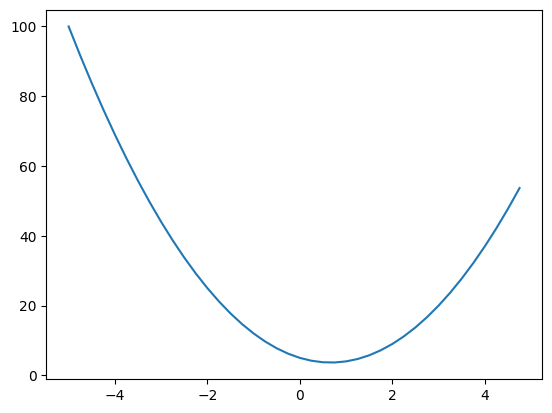

In [ ]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
h = 0.0000001
x = -3.0
f(x+h) - f(x) #this is how much the function responded in a +ve direction
(f(x+h) - f(x))/h # rise over run: slope

-21.999999688659955

too many 0, will get wrong answer becasue we are using floating point arithmetic and the represention of this number in computer memory is finite and at somepoint we get into trouble so h =x 0.00000001

In [ ]:
#complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [ ]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c
b+=h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)
#slope would be negative becase the d2<d1 coz we went down so negative
#-3 is right ansewr mathematically and analytically, in calculus differentiating a*b+c by respecr to a will give us b


d1 4.0
d2 4.0002
slope 2.0000000000042206


# ##Micrograd Manually

In [ ]:
# class Value:
#   def __init__(self, data, _children=(), _op='', label=''):
#     self.data = data
#     self._prev = set(_children) # for efficiency, its tuple but maintain in class , empty set
#     self.grad =0.0
#     self._op = _op
#     self.label = label

#   def __repr__(self):
#     return f"Value(data={self.data})"

#   def __add__(self, other):
#     out = Value(self.data+ other.data, (self, other), '+')
#     return out

#   def __mul__(self, other):
#     out = Value(self.data * other.data, (self, other), '*')
#     return out

#   def tanh(self):
#     x = self.data
#     t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
#     out = Value(t, (self, ), 'tanh')
#     return out



# a = Value(2.0, label='a')
# b = Value(-3.0, label='b')
# c = Value(10.0, label='c')
# e = a*b; e.label = 'e'
# d = e + c; d.label = 'd'
# f = Value(-2.0, label='f')
# L = d * f; L.label = 'L' #output of the graph
# L

Value(data=-8.0)

In [ ]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [ ]:
d._op

'+'

In [ ]:
from graphviz import Digraph
def trace(root):
  #build a set of all nodes and edges
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir':'LR'}) #LR lefto to tight

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    #for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
        #if this value is a result of some operation, create an OP node for it
        dot.node(name = uid + n._op, label = n._op)
        #and connect this node to it
        dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    #connect n1 to the op node
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

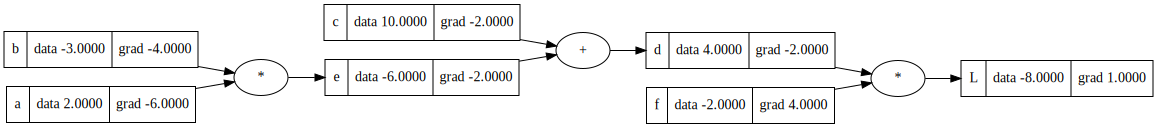

In [ ]:
draw_dot(L)

L = d* f
dl/dd = ? f

In [ ]:
#lets try to change the L with leaf node power

In [ ]:
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
f.data += 0.01*f.grad

e = a * b
d = e + c
L = d * f
print(L.data)

-8.005632000000002


In [ ]:
def lol():
  h= 0.001
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L' #output of the graph
  L1= L.data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L' #output of the graph
  L2= L.data

  print('slope', (L2-L1)/h)
lol()


slope -3.9999999999995595


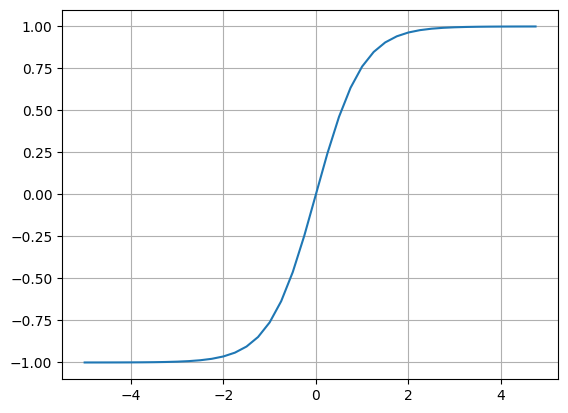

In [ ]:
plt.plot(np.arange(-5, 5, 0.25), np.tanh(np.arange(-5, 5, 0.25))); plt.grid()

In [ ]:
#2D neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.88137358, label='b')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'


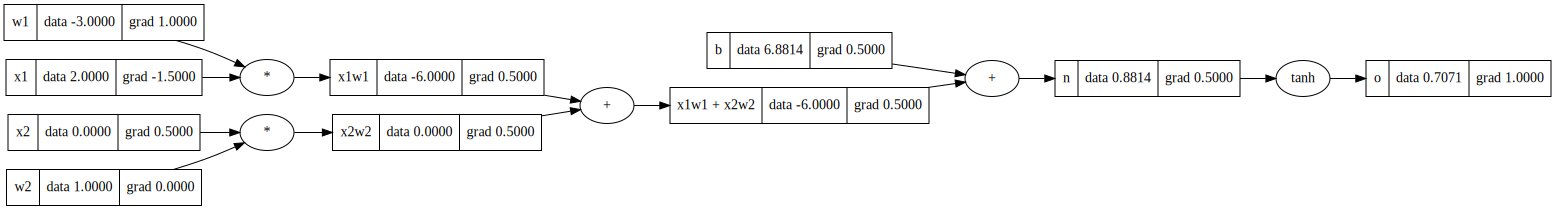

In [ ]:
draw_dot(o)

In [ ]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [ ]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

In [ ]:
x1w1.grad = 0.5
x2w2.grad = 0.5

In [ ]:
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [ ]:
n.grad = 0.5

In [ ]:
o.grad = 1.0

In [ ]:
1 - o.data ** 2

0.5000000049635664

In [ ]:
# o = tanh(n)
#do/dn = 1 - o**2 d/dx(tanh) = 1 - tanh^2

##MICROGRAD AUTOMATICALLY

In [ ]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self._prev = set(_children) # for efficiency, its tuple but maintain in class , empty set
    self.grad =0.0
    self._backward = lambda: None
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    def _backward():
      self.grad += 1.0 * out.grad #Local derivative self = 1.0 * grad
      other.grad += 1.0 * out.grad #Other derivative = 1.0 * grad as we seen du=ring manual how add is 1.0 nonetheless
    out._backward = _backward
    return out

  def __rmul__(self, other): #other * self
    return self * other

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    def _backward():
      self.grad += other.data * out.grad #local derivatibe was other.data
      other.grad += self.data * out.grad #otehr deraivative was local derivative
    out._backward = _backward
    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self, ), f'**{other}')
    def _backward():
      self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward
    return out

  def __truediv__(self, other): #self/other
    return self * other**-1

  def __neg__(self): #self - other
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp') #to let python know that self is a tuple we use (self,)
    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out





a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L' #output of the graph
L

Value(data=-8.0)

In [ ]:
a = Value(2.0)
b = Value(4.0)
a / b

Value(data=0.5)

In [188]:
#2D neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.88137358, label='b')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
#-----------------

o = n.tanh(); o.label = 'o'
o.backward()

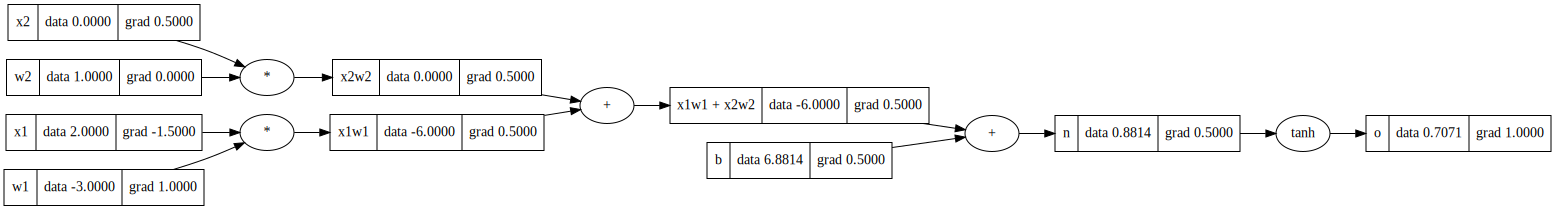

In [189]:
draw_dot(o)

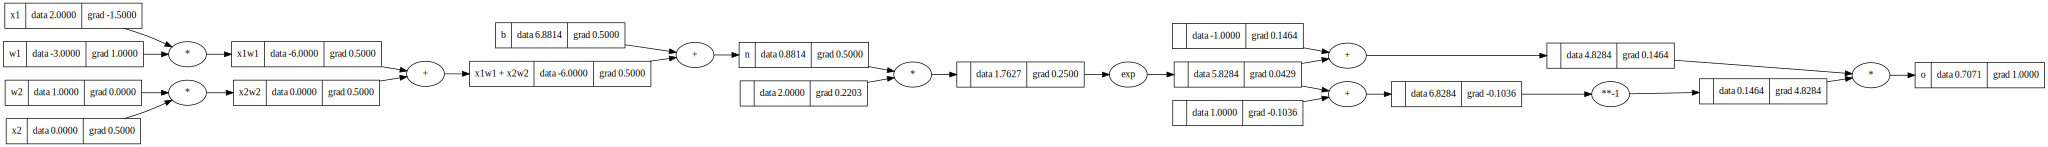

In [190]:
#2D neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.88137358, label='b')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
#-----------------
e = (2*n).exp()
o = (e - 1) / (e + 1)
#---------------
o.label = 'o'
o.backward()
draw_dot(o)

Before we do o.backward check tha self.grad = 0.0
and we cannot get 0 since everything will be 0 so we have to set the base case of 0.grad to 1.0 anything multipy to 1.0 is the same not changing value

In [ ]:
o.backward() #local deviative with global derivative

In [ ]:
o.grad = 1.0

In [ ]:
n._backward()

In [ ]:
b._backward()
x1w1x2w2._backward()

In [ ]:
x2w2._backward()
x1w1._backward()

##Now we dont want to call ._backward so think automatically how we gonna do that

In [ ]:
topo = []
visited = set()
def build_topo(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)

build_topo(o)
topo

[Value(data=6.88137358),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.88137358),
 Value(data=0.707106777676776)]

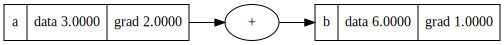

In [ ]:
#This is for the backward we have to wrie it out += backward "note += is important coz if the value is repeaed more than 1 time it should do the math properly"
a = Value(3.0, label='a')
b = a + a; b.label ='b'
b.backward()
draw_dot(b)

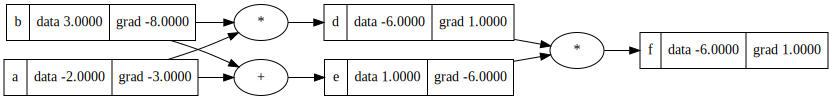

In [ ]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label ='d'
e = a + b; e.label ='e'
f = d * e; f.label ='f'
f.backward()
draw_dot(f)

In [192]:
import torch
x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
print(o.data.item())
o.backward()

print('----')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


#Lets build NN

In [236]:
import random
class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]

    self.b = Value(random.uniform(-1,1))


  def __call__(self,x):
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]
    # params =[]
    # for neuron in self.neurons:
    #   ps = neuron.parameters()
    #   params.extend(ps)
    # return params

class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]



In [237]:
x = [2.0,3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

Value(data=-0.15183359591542048)

In [238]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] #desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.15183359591542048),
 Value(data=0.6625372838505789),
 Value(data=0.11307551921197848),
 Value(data=0.5067068415334564)]

In [239]:
#to better predict is for deep learning, calculate the single number that somehow measure the total perfoermance of Neural net, that is called Loss

In [240]:
loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0.0)) #how well neural net is performing since the desired result is way of as you can see from above prediction
loss

Value(data=5.573026104531623)

In [241]:
loss.backward()

In [242]:
n.layers[0].neurons[0].w[0].grad

-0.0338776164948921

In [244]:
n.layers[0].neurons[0].w[0].data

0.7772652221474279

In [ ]:
for p in n.parametrs():
  p.data += -0.01 * p.grad

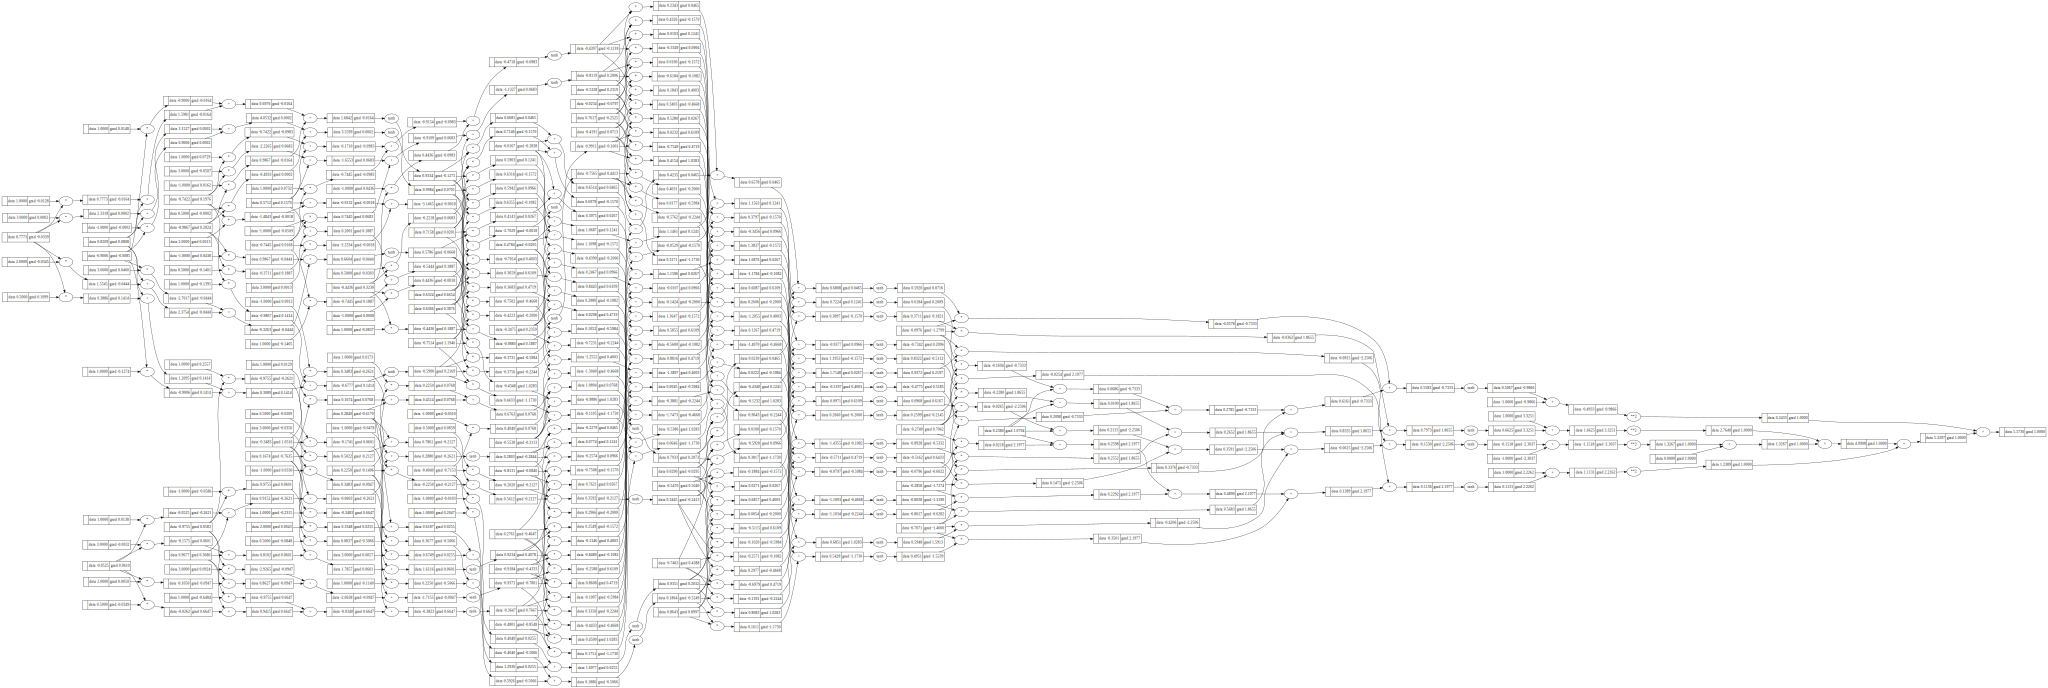

In [243]:
draw_dot(loss)